In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'

def plot_bias_metrics(adata, bias_metrics):
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
    axes = axes.flatten()
    for i, bias_metric in enumerate(bias_metrics) : 
        adata.obs[bias_metric].hist(ax=axes[i], bins=50, edgecolor='white')
        axes[i].set_title(bias_metric)
        axes[i].grid(alpha=0.2)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [2]:
adata = sc.read_h5ad("/project/cfRNA_Disentaglement/Data/OpenAccess/Processed/Merged.h5ad")
bias_metrics = ['gc_bias_score', 'len_bias_score', 'platelet_score', 'log1p_total_counts', 'NG80', 'NP80', 'NP80_NG80_ratio','FSR']

adata.obs['FSR'] = adata.obs['FSR'].fillna(0)

# 3. 불리언 마스크를 단계별로 계산 (가독성과 메모리 관리)
mask = (adata.obs['log1p_total_counts'] > 10) & \
       (adata.obs['NP80_NG80_ratio'] > 0) & \
       (adata.obs['NP80_NG80_ratio'] < 50) & \
       (adata.obs['FSR'] > 0) & \
       (adata.obs['Phenotype'] != 'nan') # Phenotype 결측치 제거

# 결측치 체크 (전체 복사 대신 인덱스만 추출)
not_na_mask = adata.obs[bias_metrics].notna().all(axis=1)
final_mask = mask & not_na_mask

# 4. 필터링 결과 확인 (복사본 만들기 전 수행)
n_before = adata.n_obs
n_after = final_mask.sum()
n_dropped = n_before - n_after

# 5. 최종 데이터만 남기기 (기존 adata를 덮어씌워 메모리 확보)
adata = adata[final_mask].copy() 

print(f"### 필터링 결과 요약 ###")
print(f"* 필터링 전 샘플 수: {n_before}")
print(f"* 필터링 후 샘플 수: {n_after}")
print(f"* 삭제된 샘플 수: {n_dropped} ({ (n_dropped/n_before)*100:.2f}%)")

### 필터링 결과 요약 ###
* 필터링 전 샘플 수: 2154
* 필터링 후 샘플 수: 2073
* 삭제된 샘플 수: 81 (3.76%)


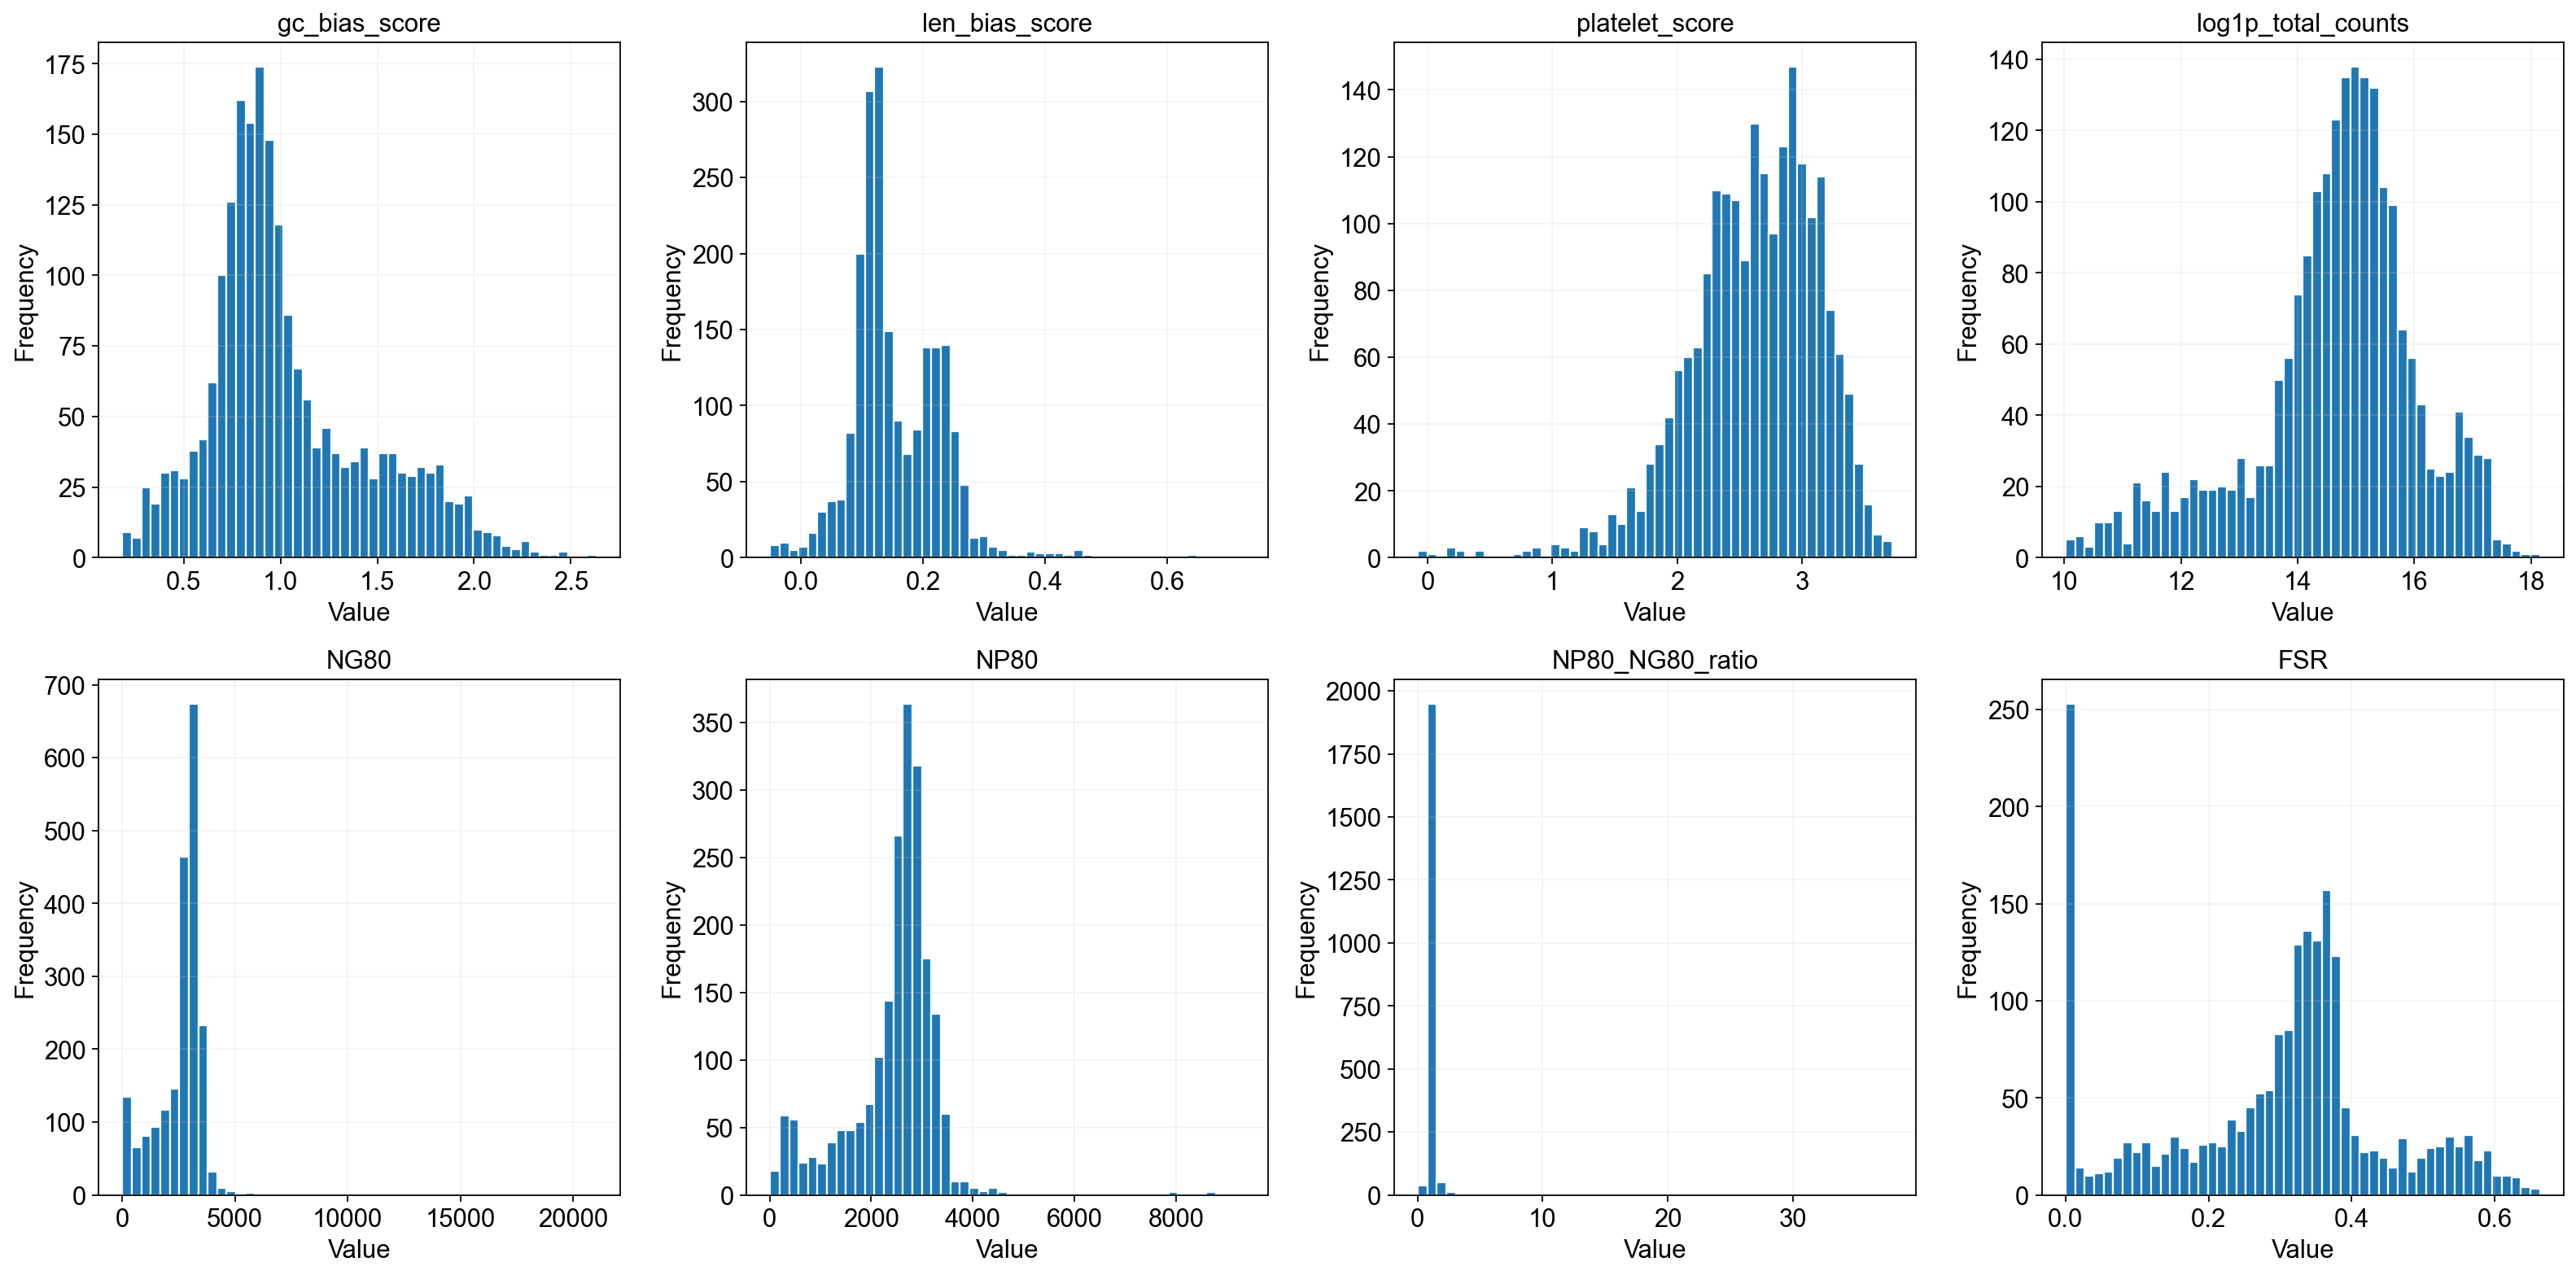

In [27]:
plot_bias_metrics(adata, bias_metrics)

Step 1 완료: 18515 유전자 남음
Step 2: 벡터화 연산 시작 (Fast Spearman)...


/tmp/ipykernel_28164/4245266682.py:44: RuntimeWarning: invalid value encountered in divide
  norm_data = (ranked_data - ranked_data.mean(axis=0)) / ranked_data.std(axis=0)


Step 4 & 5: 압축 및 보험 유전자 결합...


/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

최종 유전자 수: 3394


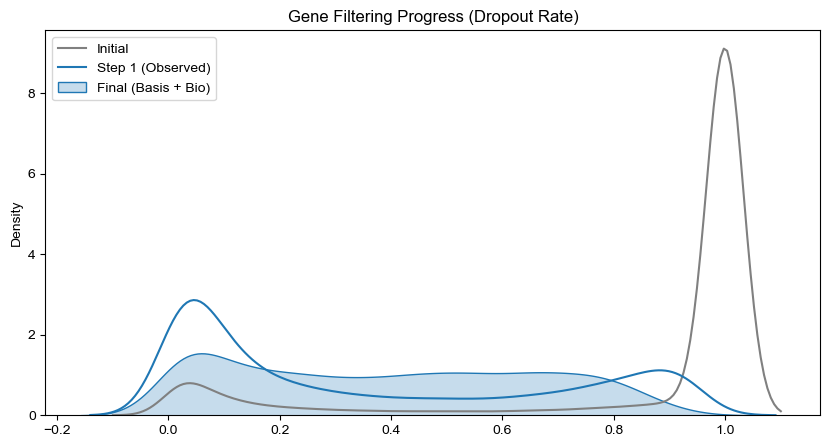

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import FeatureAgglomeration
from sklearn.linear_model import LinearRegression

# --- 0. 설정 ---
study_col = 'Batch_Granular'
bias_metrics = ['gc_bias_score', 'len_bias_score', 'platelet_score', 'log1p_total_counts', 'NG80', 'NP80', 'NP80_NG80_ratio', 'FSR']
layer = 'Standard_LogCPM'

# 1. 데이터 추출 및 기초 필터링 (Step 1)
# 메모리 절약을 위해 필요한 레이어만 로드
expr_all = adata.layers[layer]
if hasattr(expr_all, "toarray"): expr_all = expr_all.toarray()

n_samples, n_genes_total = adata.shape
obs_ratio = (expr_all > 0).mean(axis=0)
keep_step1 = obs_ratio >= 0.05
print(f"Step 1 완료: {keep_step1.sum()} 유전자 남음")

### --- [핵심 최적화: 벡터화된 Study별 상관계수 계산] --- ###
def get_fast_spearman_counts(data, obs_df, studies, metrics, threshold=0.2):
    """루프 없이 행렬 연산으로 스피어먼 상관계수 히트 카운트 계산"""
    gene_hits = np.zeros((data.shape[1], len(metrics)))
    valid_studies = 0
    
    for study in studies:
        idx = obs_df[study_col] == study
        if idx.sum() < 20: continue
        valid_studies += 1
        # 1. Rank 변환 (Spearman의 핵심) - 이 부분이 루프를 대체함
        sub_data = data[idx.values]
        ranked_data = pd.DataFrame(sub_data).rank().values
        # 2. 유전계별 표준편차 체크 (모두 0인 경우 제외)
        std_mask = np.std(ranked_data, axis=0) > 0
        for m_idx, metric in enumerate(metrics):
            qc_vals = pd.Series(obs_df.loc[idx, metric]).rank().values
            if np.std(qc_vals) == 0: continue
            # 3. 벡터화된 상관계수 계산 (Pearson on Ranks)
            # (N, G)와 (N,)의 상관관계를 한 번에 계산
            norm_data = (ranked_data - ranked_data.mean(axis=0)) / ranked_data.std(axis=0)
            norm_qc = (qc_vals - qc_vals.mean()) / qc_vals.std()
            corrs = np.dot(norm_data.T, norm_qc) / (len(qc_vals) - 1)
            
            # 4. 기준치 넘는 히트 카운트 누적
            gene_hits[std_mask, m_idx] += (np.abs(corrs[std_mask]) >= threshold)
            
    return gene_hits, valid_studies

print("Step 2: 벡터화 연산 시작 (Fast Spearman)...")
# Step 1을 통과한 유전자들만 대상으로 계산
study_hits, n_eff = get_fast_spearman_counts(
    expr_all[:, keep_step1], 
    adata.obs, 
    adata.obs[study_col].unique(), 
    bias_metrics
)

# 전체 유전자 인덱스로 복구
keep_step2_sub = study_hits.max(axis=1) >= (n_eff * 0.5)
keep_step2 = np.zeros(n_genes_total, dtype=bool)
keep_step2[np.where(keep_step1)[0]] = keep_step2_sub

### --- [Step 4 & 5 통합: 압축 및 보험] --- ###
print("Step 4 & 5: 압축 및 보험 유전자 결합...")
basis_idx = np.where(keep_step2)[0]
X_bias = adata.obs[bias_metrics].values
reg = LinearRegression().fit(X_bias, expr_all[:, basis_idx])
Y_hat = reg.predict(X_bias)

# Feature Agglomeration (중복 제거)
agglo = FeatureAgglomeration(n_clusters=min(3000, len(basis_idx)), linkage='average', metric='cosine')
agglo.fit(Y_hat)
compressed_idx = [basis_idx[agglo.labels_ == c][0] for c in np.unique(agglo.labels_)]

# Step 5 (보험 유전자들)
if 'Phenotype' in adata.obs.columns:
    sc.tl.rank_genes_groups(adata, groupby='Phenotype',
                            method='wilcoxon', layer=layer, n_genes=500)
    df = sc.get.rank_genes_groups_df(adata, group=None)  # 모든 group concat
    bio_genes = df['names'].head(500).values
    keep_bio = adata.var_names.isin(bio_genes)

else:
    keep_bio = np.zeros(n_genes_total, dtype=bool)
    keep_bio[np.argsort(np.var(expr_all, axis=0))[-500:]] = True

final_mask = np.zeros(n_genes_total, dtype=bool)
final_mask[compressed_idx] = True
final_mask |= keep_bio

# --- 최종 결과 ---
adata_final = adata[:, final_mask].copy()
print(f"최종 유전자 수: {adata_final.n_vars}")

# 간단 요약 시각화 (통합본)
all_dropout = (expr_all == 0).mean(axis=0)
plt.figure(figsize=(10, 5))
sns.kdeplot(all_dropout, label='Initial', color='grey')
sns.kdeplot(all_dropout[keep_step1], label='Step 1 (Observed)')
sns.kdeplot(all_dropout[final_mask], label='Final (Basis + Bio)', fill=True)
plt.title("Gene Filtering Progress (Dropout Rate)")
plt.legend(); plt.show()

AnnData object with n_obs × n_vars = 2073 × 3394
    obs: 'Assay.Type', 'AvgSpotLen', 'Bases', 'BioProject', 'Center.Name', 'BioSample', 'Bytes', 'Instrument', 'LibraryLayout', 'LibrarySelection', 'version', 'Sample.Name', 'AGE', 'tissue', 'Library.Name', 'sex', 'BioSampleModel', 'isolate', 'Replicate_Group', 'Phenotype', 'disease_stage', 'Batch_Granular', 'Type_Granular', 'align_input', 'align_multi', 'align_tooshort', 'align_unique', 'bfcohort', 'bias53', 'cad4tb_score', 'duplication_rate', 'exon_ratio', 'exonic_reads', 'extract_date', 'ftcount', 'hiv', 'intergenic_reads', 'intron_exon_ratio', 'intronic_reads', 'library_prep_date', 'lunit_score', 'micro_ref_stndrd', 'mtrna_reads', 'nuclear_reads', 'passqc', 'qxr_score', 'reads_all', 'reads_trimmed_filtered', 'rrna_fraction', 'rrna_reads', 'sample_group_granular', 'site', 'volume', 'semiquant', 'Assigned', 'Status', 'Unassigned_Ambiguity', 'Unassigned_Chimera', 'Unassigned_Duplicate', 'Unassigned_FragmentLength', 'Unassigned_MappingQu

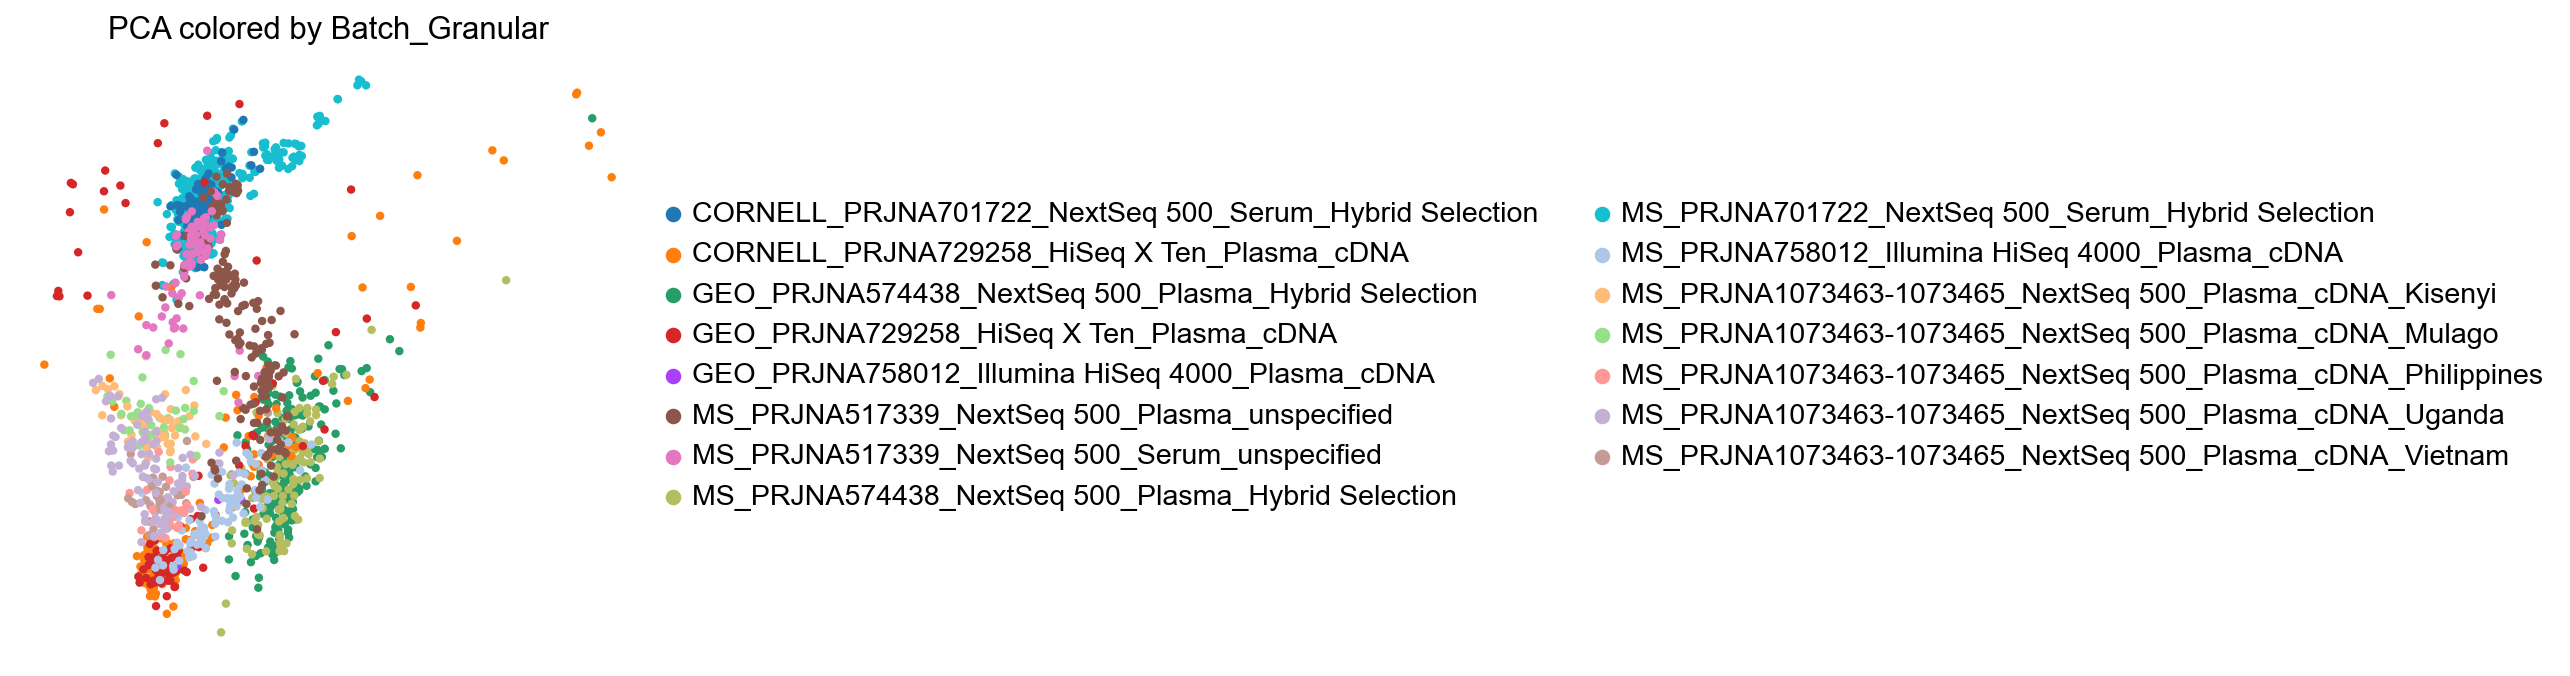

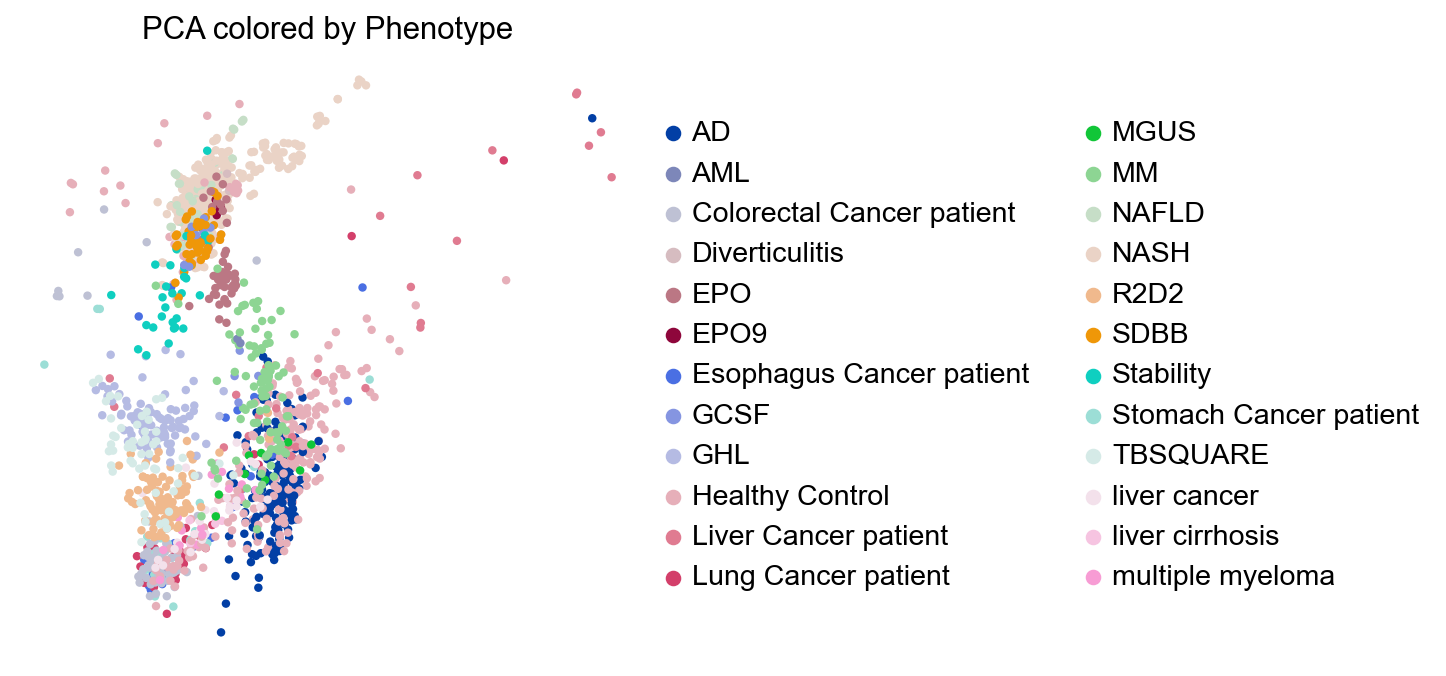

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# 시각화 설정 (선택)
sc.settings.set_figure_params(figsize=(5, 5), frameon=False)
study_col = 'Batch_Granular'
condition_col = 'Phenotype'  # 없으면 자동으로 처리하게 아래에서 방어 코드 넣을 거야
bias_metrics = ['gc_bias_score', 'len_bias_score', 'platelet_score',
                'log1p_total_counts', 'NG80', 'NP80',
                'NP80_NG80_ratio', 'FSR']

print(adata_final)
print("n_samples:", adata_final.n_obs, "n_genes:", adata_final.n_vars)
# 2-1. PCA용으로 .X를 설정 (Standard_LogCPM 사용)
layer = 'Standard_LogCPM'

X_expr = adata_final.layers[layer]
if hasattr(X_expr, "toarray"):
    X_expr = X_expr.toarray()

adata_pca = adata_final.copy()
adata_pca.X = X_expr.astype(np.float32)

# 2-2. 기본 전처리 + PCA
sc.pp.scale(adata_pca, zero_center=True, max_value=10)  # outlier clipping
sc.tl.pca(adata_pca, n_comps=30, svd_solver='arpack')

# 2-3. PCA 시각화: 배치 기준
sc.pl.pca(
    adata_pca,
    color=study_col,
    title=f"PCA colored by {study_col}",
    legend_loc='right margin'
)

# 2-4. PCA 시각화: Condition 기준 (있을 때만)
if condition_col in adata_pca.obs.columns:
    sc.pl.pca(
        adata_pca,
        color=condition_col,
        title=f"PCA colored by {condition_col}",
        legend_loc='right margin'
    )
else:
    print(f"Column '{condition_col}' not found in adata.obs; skipping Condition PCA plot.")

In [5]:
adata_final.write_h5ad("OpenAccess_Filtered.h5ad")